In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
bank = pd.read_csv('/Users/rodrigoantunez/Documents/Data Analytics/Python_Advanced/bank-additional.csv')
bank

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,19154,NaN,admin.,MARRIED,university.degree,0.0,0.0,0.0,cellular,618,...,1.4,"93,444","-36,1",NaN,"5228,1",yes,13-octubre-2015,38.147,-105.582,4eed05de-2a98-4227-b488-32122009b638
42996,26206,34.0,technician,MARRIED,professional.course,0.0,1.0,1.0,cellular,42,...,-0.1,"93,2",-42,NaN,"5195,8",no,17-marzo-2018,49.235,-112.201,0f0aca88-4088-4fe2-905f-44fb675d9493
42997,15046,NaN,blue-collar,SINGLE,basic.6y,0.0,1.0,0.0,cellular,391,...,1.4,"93,918","-42,7",NaN,"5228,1",no,15-septiembre-2016,40.679,-120.015,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b
42998,15280,NaN,admin.,MARRIED,university.degree,NaN,0.0,0.0,cellular,674,...,1.4,"93,918","-42,7","4,958","5228,1",no,23-septiembre-2019,27.772,-117.518,5f432048-d515-4bb5-9c94-62db451f88d4


In [3]:
#visualizo brevemente formatos de las variables 
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [4]:
#visualizo los valores nulos en proporción al total de cada variable 
bank.isnull().sum() / len(bank)*100

Unnamed: 0         0.000000
age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      0.000000
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id_                0.000000
dtype: float64

In [5]:
#forma alternativa para lo ver valores nulos
bank.isna().sum() / (bank.shape[0])*100

Unnamed: 0         0.000000
age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      0.000000
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id_                0.000000
dtype: float64

In [6]:
#chequeo que no haya duplicados 
bank.duplicated().sum()

np.int64(0)

In [7]:
#importo el otro archivo a trabajar (un xlsx complementario a mi base de datos csv)
customer = pd.read_excel('/Users/rodrigoantunez/Documents/Data Analytics/Python_Advanced/unified-customer-details.xlsx')
customer 

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...,...
43165,43165,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4
43166,43166,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6
43167,43167,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093
43168,43168,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb


In [8]:
#creo una copia del dataframe original para trabajar en ella
bank_df = bank.copy()

In [9]:
#renombro la columna 'id_' para que coincida con la columna 'ID' del dataframe 'customer' y así poder unificar ambos dataframe en uno solo 
bank_df.rename(columns={'id_': 'ID'}, inplace='True')
bank_df.head(3)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,ID
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b


In [10]:
#unifico los dos dataframes 'bank_df' y 'customer' para tener toda la información de ambas bases de datos 
df = bank_df.merge(customer, how='left', on= 'ID')

In [11]:
df.sample(5)

,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,date,latitude,longitude,ID,Unnamed: 0_y,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
4244,4341,43.0,admin.,MARRIED,high.school,0.0,1.0,0.0,telephone,360,...,25-junio-2019,41.315,-92.909,20aa2302-0613-4ffa-99f8-944bdf91a41e,4341,13367,1,1,2012-12-12,11
23620,23717,44.0,blue-collar,MARRIED,NaN,NaN,1.0,0.0,cellular,68,...,23-febrero-2019,46.038,-84.883,1ecc8dee-c79b-4cab-89b9-4cd3655dc3f9,23717,124655,0,1,2013-02-18,9
10690,10787,32.0,technician,DIVORCED,professional.course,0.0,1.0,0.0,telephone,269,...,14-mayo-2017,26.504,-69.404,c3d19428-ff32-4303-9e91-7e5f7a899230,10787,148289,0,1,2012-08-13,16
9917,10014,53.0,NaN,MARRIED,high.school,NaN,0.0,0.0,telephone,89,...,15-octubre-2016,36.972,-82.400,16728796-fa19-483f-9ef3-45e1ca415722,10014,80615,0,0,2012-01-16,10
11993,12090,35.0,blue-collar,MARRIED,basic.6y,0.0,0.0,0.0,telephone,281,...,5-mayo-2015,31.769,-116.083,c45270fc-cf60-4b78-bb47-e473c64e4749,12090,155133,1,1,2012-12-26,15


In [12]:
#creo un diccionario para renombrar las etiquetas de columnas en español
nuevos_nombres = {
    'Unnamed: 0_x':'ref_x',
    'age':'edad',
    'job':'empleo',
    'marital':'estado_civil',
    'education':'nivel_educativo',
    'default':'morosidad',
    'housing':'hipoteca',
    'loan':'prestamos',
    'contact':'via_contacto',
    'duration':'duracion_llam',
    'campaign':'num_llam',
    'pdays':'dias_ult.llam',
    'previous':'num_llam.camp.previa',
    'poutcome':'result_camp.previa',
    'emp.var.rate':'variacion_empleo',
    'cons.price.idx':'id_precio.cons',
    'cons.conf.idx':'id_confza.cons',
    'euribor3m':'tasa_interes.3m',
    'nr.employed':'id_empleado',
    'y':'prod.serv_susc',
    'date':'fecha_llam',
    'latitude':'latitud',
    'longitude':'longitud',
    'contact_month':'mes_llam',
    'contact_year':'año_llam',
    'ID':'id_ref',
    'Unnamed: 0_y':'ref_y',
    'Income':'ingreso_anual',
    'Kidhome':'num_niños.hogar',
    'Teenhome':'num_joven.hogar',
    'Dt_Customer':'fecha_incio.cliente',
    'NumWebVisitsMonth':'num.visitas.web_mes'
}

In [13]:
#aplico el diccionario creado 
df.rename(columns= nuevos_nombres, inplace= True)

In [14]:
print(df.columns)

Index(['ref_x', 'edad', 'empleo', 'estado_civil', 'nivel_educativo',
       'morosidad', 'hipoteca', 'prestamos', 'via_contacto', 'duracion_llam',
       'num_llam', 'dias_ult.llam', 'num_llam.camp.previa',
       'result_camp.previa', 'variacion_empleo', 'id_precio.cons',
       'id_confza.cons', 'tasa_interes.3m', 'id_empleado', 'prod.serv_susc',
       'fecha_llam', 'latitud', 'longitud', 'id_ref', 'ref_y', 'ingreso_anual',
       'num_niños.hogar', 'num_joven.hogar', 'fecha_incio.cliente',
       'num.visitas.web_mes'],
      dtype='str')


In [15]:
#visualizo mi dataframe ahora
df.head(5)

,ref_x,edad,empleo,estado_civil,nivel_educativo,morosidad,hipoteca,prestamos,via_contacto,duracion_llam,...,fecha_llam,latitud,longitud,id_ref,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20


In [16]:
#creo otro diccionario para modificar los datos de la columna 'empleo' a español
empleos_espanol = {
    'housemaid':'emp.doméstica',
    'services':'servicios',
    'admin.':'administrativo',
    'blue-collar':'obrero',
    'entrepreneur':'emprendedor',
    'management':'directivo',
    'retired':'jubilado',
    'self-employed':'autónomo',
    'student':'estudiante',
    'technician':'técnico',
    'unemployed':'desempleado'
    }

In [17]:
#ejecuto el diccionario
df['empleo'] = df['empleo'].replace(empleos_espanol)

In [18]:
#cambio el contenido de 'estado_civil' a español 
df['estado_civil'] = df['estado_civil'].replace({'SINGLE':'soltero/a', 'MARRIED':'casado/a', 'DIVORCED':'divorciado/a'}, regex=True)

In [19]:
#creo otro diccionario para cambiar y aclarar la información de la columna 'nivel_educativo' 
clasifico_educativo = {
    'basic.4y':'basico.(4años)',
    'basic.6y':'basico.(6años)',
    'basic.9y':'basico.(9años)',
    'high.school':'secundaria',
    'illiterate':'analfabeto/a',
    'professional.course':'form_profesional',
    'university.degree':'universitario'
}

In [20]:
#ejecuto el diccionario 
df['nivel_educativo'] = df['nivel_educativo'].replace((clasifico_educativo), regex=True)

In [21]:
#Ídem para la columna 'via_contacto'
df['via_contacto'] = df['via_contacto'].replace({'telephone':'telefono', 'cellular':'móvil'}, regex=True)

In [22]:
#ídem para la columna 'resultado de campaña previa'
df['result_camp.previa'] = df['result_camp.previa'].replace({'NONEXISTENT':'inexistente', 'FAILURE':'sin_exito', 'SUCCESS':'exitosa'}, regex=True)

In [23]:
#otro vistazo a mi dataframe hasta aquí
df.sample(5)

,ref_x,edad,empleo,estado_civil,nivel_educativo,morosidad,hipoteca,prestamos,via_contacto,duracion_llam,...,fecha_llam,latitud,longitud,id_ref,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
28653,28797,38.0,administrativo,casado/a,secundaria,0.0,1.0,0.0,móvil,302,...,22-abril-2016,35.084,-122.442,87fb8b4c-1405-48b1-bf23-486497d8e44b,28797,95927,1,0,2013-07-16,9
11388,11485,30.0,obrero,soltero/a,basico.(4años),NaN,0.0,0.0,telefono,402,...,2-agosto-2016,27.027,-123.185,da5ca4b3-8039-4f73-8194-2cb544ae41ae,11485,73908,0,0,2012-09-09,14
14750,14847,31.0,directivo,soltero/a,universitario,0.0,0.0,0.0,móvil,143,...,27-agosto-2018,35.434,-92.528,862c2ff5-e7f2-4609-9f28-69c829769267,14847,137427,2,2,2012-06-19,28
10139,10236,33.0,técnico,casado/a,secundaria,NaN,1.0,0.0,telefono,119,...,24-junio-2015,30.845,-76.080,7708a054-b39f-4233-bdb8-d8e63c1d224a,10236,97954,2,1,2012-04-01,7
41568,17509,48.0,técnico,casado/a,form_profesional,0.0,1.0,0.0,móvil,383,...,30-noviembre-2016,35.572,-111.777,871203ac-1e53-4e4a-bf07-9f7a558e2286,41735,118559,2,2,2014-07-14,22


In [24]:
#observo los estadísticos principales de mi dataframe
df.describe()

,ref_x,edad,morosidad,hipoteca,prestamos,duracion_llam,num_llam,dias_ult.llam,num_llam.camp.previa,variacion_empleo,latitud,longitud,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067,21618.425209,93241.200070,1.004791,0.998605,2013-05-12 07:05:06.083721,16.589698
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250,10846.750000,49610.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500,21596.500000,93050.500000,1.000000,1.000000,2013-03-02 00:00:00,17.000000
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750,32393.250000,136744.500000,2.000000,2.000000,2014-03-29 00:00:00,25.000000
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000,43166.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282,12440.247128,50498.316182,0.815913,0.815983,NaN,9.239205


In [25]:
#observo los formatos de las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ref_x                 43000 non-null  int64         
 1   edad                  37880 non-null  float64       
 2   empleo                42655 non-null  str           
 3   estado_civil          42915 non-null  str           
 4   nivel_educativo       41193 non-null  str           
 5   morosidad             34019 non-null  float64       
 6   hipoteca              41974 non-null  float64       
 7   prestamos             41974 non-null  float64       
 8   via_contacto          43000 non-null  str           
 9   duracion_llam         43000 non-null  int64         
 10  num_llam              43000 non-null  int64         
 11  dias_ult.llam         43000 non-null  int64         
 12  num_llam.camp.previa  43000 non-null  int64         
 13  result_camp.previa    43000

In [26]:
#observo la cantidad de nulos en proporción a cada varibale y luego comienzo el tratamiento (imputación) de los mismo
df.isnull().sum() / len(df)*100

ref_x                    0.000000
edad                    11.906977
empleo                   0.802326
estado_civil             0.197674
nivel_educativo          4.202326
morosidad               20.886047
hipoteca                 2.386047
prestamos                2.386047
via_contacto             0.000000
duracion_llam            0.000000
num_llam                 0.000000
dias_ult.llam            0.000000
num_llam.camp.previa     0.000000
result_camp.previa       0.000000
variacion_empleo         0.000000
id_precio.cons           1.095349
id_confza.cons           0.000000
tasa_interes.3m         21.525581
id_empleado              0.000000
prod.serv_susc           0.000000
fecha_llam               0.576744
latitud                  0.000000
longitud                 0.000000
id_ref                   0.000000
ref_y                    0.000000
ingreso_anual            0.000000
num_niños.hogar          0.000000
num_joven.hogar          0.000000
fecha_incio.cliente      0.000000
num.visitas.we

In [27]:
#comienzo con la variable 'morosidad', para ello visualizo sus valores
print(df['morosidad'].value_counts())

morosidad
0.0    34016
1.0        3
Name: count, dtype: int64


In [28]:
#dado que observo solo 3 clientes morosos, adopto la no morosidad como Status-Quo y completo los nulos con ceros
df['morosidad'] = df['morosidad'].fillna(0)

In [29]:
#para la varibale edad, visualizo moda, mediana y media y luego procedo a completar los nulos
media_edad = df['edad'].mean()
mediana_edad = df['edad'].median()
moda_edad = df['edad'].mode()[0]

print(f'Media: {media_edad}')
print(f'Mediana: {mediana_edad}')
print(f'Moda: {moda_edad}')

Media: 39.97711193241816
Mediana: 38.0
Moda: 31.0


In [30]:
#completo los nulos con la mediana (que es más robusta) y no se ve afectada por valores extremos (como algunos pocos clientes de +90 años)
df['edad'] = df['edad'].fillna(mediana_edad)

In [31]:
#chequeo que no hayan nulos para 'edad' 
df['edad'].isnull().sum()

np.int64(0)

In [32]:
#limpio y adapto la columna 'tasa_interes.3m' para trabajar correctamente con pandas
df['tasa_interes.3m'] = df['tasa_interes.3m'].astype(str).str.replace(',', '.')

In [33]:
#convierto a formato float manteniendo los nulos ('coerce' asegura que los nulos sigan siendo NaN)
df['tasa_interes.3m'] = pd.to_numeric(df['tasa_interes.3m'], errors='coerce')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ref_x                 43000 non-null  int64         
 1   edad                  43000 non-null  float64       
 2   empleo                42655 non-null  str           
 3   estado_civil          42915 non-null  str           
 4   nivel_educativo       41193 non-null  str           
 5   morosidad             43000 non-null  float64       
 6   hipoteca              41974 non-null  float64       
 7   prestamos             41974 non-null  float64       
 8   via_contacto          43000 non-null  str           
 9   duracion_llam         43000 non-null  int64         
 10  num_llam              43000 non-null  int64         
 11  dias_ult.llam         43000 non-null  int64         
 12  num_llam.camp.previa  43000 non-null  int64         
 13  result_camp.previa    43000

In [35]:
#para 'tasa_interes.3m' decido hacer una imputación aplicando el método de "interpolación lineal" con los valores adyacentes. Pero para esto, los valores deben estar ordenados por fecha.
#entonces procedo a formatear la fecha al inglés y luego ordernar por esa varibale
meses_es_en = { 
    'enero': 'Jan',
    'febrero': 'Feb',
    'marzo': 'Mar', 
    'abril': 'Apr',
    'mayo': 'May',
    'junio': 'Jun',
    'julio': 'Jul',
    'agosto': 'Aug',
    'septiembre': 'Sep',
    'octubre': 'Oct',
    'noviembre': 'Nov',
    'diciembre': 'Dec'
}

In [36]:
#aplico el diccionario a la columna 'fecha_llam'
df['fecha_llam'] = df['fecha_llam'].replace(meses_es_en, regex = True)

In [37]:
#convierto a formato 'datetime' (formato: Dia-Mes-Año)
df['fecha_llam'] = pd.to_datetime(df['fecha_llam'], format= '%d-%b-%Y', errors='coerce')

In [38]:
#ordeno el dataframe cronológicamente por fecha
df = df.sort_values(by='fecha_llam')

In [39]:
df.head(5)

,ref_x,edad,empleo,estado_civil,nivel_educativo,morosidad,hipoteca,prestamos,via_contacto,duracion_llam,...,fecha_llam,latitud,longitud,id_ref,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
32486,32630,25.0,administrativo,casado/a,universitario,0.0,0.0,0.0,móvil,496,...,2015-01-01,33.363,-88.524,03a8b52f-0156-48a8-89dd-7cf01556580b,32630,175161,0,0,2014-06-23,8
20246,20343,53.0,administrativo,divorciado/a,universitario,0.0,0.0,0.0,móvil,506,...,2015-01-01,43.388,-88.537,ad17285f-6825-4301-acd9-28f9e05baed5,20343,84873,0,2,2013-08-21,5
13562,13659,38.0,técnico,soltero/a,form_profesional,0.0,1.0,0.0,móvil,268,...,2015-01-01,45.972,-107.830,4e0c17e7-331f-4db6-a4e6-3e7bf336eae8,13659,144114,0,2,2012-02-28,11
7297,7394,51.0,servicios,casado/a,secundaria,0.0,1.0,0.0,telefono,85,...,2015-01-01,46.265,-102.194,533cc8a8-7433-4963-9d59-11d030961d4c,7394,101033,2,1,2012-01-31,9
10739,10836,30.0,servicios,casado/a,secundaria,0.0,1.0,0.0,telefono,421,...,2015-01-01,26.014,-114.897,2b744cce-f877-4db0-8b8a-f95c6ab86030,10836,152674,2,0,2012-01-28,28


In [40]:
#ahora sí, para 'tasa_interes.3m' relleno los nulos con función 'interpolate' haciendo una pequeña interpolación lineal para cada uno de los nulos con sus valores adyacentes (en otras palabras es una media entre datos vecinos)
df['tasa_interes.3m'] = df['tasa_interes.3m'].interpolate(method='linear')

In [41]:
#chequeo rápidamente como quedó la columna
print('Valores más frecuentes:')
print(df['tasa_interes.3m'].value_counts().head(10))

print(f'Cantidad de nulos: {df['tasa_interes.3m'].isnull().sum()}')

Valores más frecuentes:
tasa_interes.3m
4.857    2335
4.962    2230
4.963    2120
4.961    1664
4.964    1018
4.856     987
1.405     961
4.965     909
4.960     892
4.864     877
Name: count, dtype: int64
Cantidad de nulos: 0


In [42]:
#visualizo un poco el dataframe (utilizando la extensión "Data Wrangler" de Microsoft) que es muy amigable para ir controlando los resultados 
df.sample(8)

,ref_x,edad,empleo,estado_civil,nivel_educativo,morosidad,hipoteca,prestamos,via_contacto,duracion_llam,...,fecha_llam,latitud,longitud,id_ref,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
11707,11804,45.0,directivo,soltero/a,basico.(9años),0.0,1.0,0.0,telefono,294,...,2019-08-07,35.165,-80.759,387c566b-6c47-4c1b-b483-155f0560eaee,11804,80996,1,2,2012-03-22,20
7025,7122,41.0,emp.doméstica,casado/a,universitario,0.0,0.0,0.0,telefono,665,...,2016-08-29,40.286,-109.295,ea7353ef-a966-4f5b-bdd0-6d9d8f96014a,7122,116530,0,0,2012-03-16,11
3369,3466,40.0,servicios,soltero/a,secundaria,0.0,1.0,0.0,telefono,381,...,2018-11-30,34.990,-73.394,7900c309-a310-4e22-b439-196965f11d84,3466,18634,1,1,2012-09-11,27
17567,17664,53.0,obrero,casado/a,secundaria,0.0,0.0,1.0,móvil,136,...,2015-12-02,27.373,-76.219,6ae2538b-2f97-49cb-b0ec-1139657b9da1,17664,170083,1,0,2012-05-25,14
25159,25281,37.0,directivo,soltero/a,universitario,0.0,1.0,0.0,móvil,242,...,2018-05-31,24.661,-96.648,2500ed78-0932-4c45-af8e-eb27b4c98927,25281,70883,1,1,2013-05-03,14
36971,37138,38.0,técnico,soltero/a,form_profesional,0.0,1.0,0.0,móvil,251,...,2019-03-12,44.111,-89.725,d1235ff7-7a34-4977-b8b5-06bc7aac4d9c,37138,166553,0,2,2014-09-28,19
21837,21934,31.0,técnico,casado/a,universitario,0.0,0.0,0.0,móvil,195,...,2015-03-27,26.570,-86.174,2e2823b7-b940-4e94-998a-4574cd0bb4d2,21934,90728,2,1,2013-08-13,10
23830,23927,53.0,autónomo,casado/a,universitario,0.0,1.0,0.0,móvil,47,...,2019-04-25,36.451,-70.464,acd76f00-03fd-4393-8542-00d502c5dcc2,23927,106957,2,2,2013-08-13,14


In [43]:
#observo los valores nulos que aún tengo en mi dataframe 
df.isnull().sum() / len(df)*100

ref_x                   0.000000
edad                    0.000000
empleo                  0.802326
estado_civil            0.197674
nivel_educativo         4.202326
morosidad               0.000000
hipoteca                2.386047
prestamos               2.386047
via_contacto            0.000000
duracion_llam           0.000000
num_llam                0.000000
dias_ult.llam           0.000000
num_llam.camp.previa    0.000000
result_camp.previa      0.000000
variacion_empleo        0.000000
id_precio.cons          1.095349
id_confza.cons          0.000000
tasa_interes.3m         0.000000
id_empleado             0.000000
prod.serv_susc          0.000000
fecha_llam              0.576744
latitud                 0.000000
longitud                0.000000
id_ref                  0.000000
ref_y                   0.000000
ingreso_anual           0.000000
num_niños.hogar         0.000000
num_joven.hogar         0.000000
fecha_incio.cliente     0.000000
num.visitas.web_mes     0.000000
dtype: flo

In [44]:
#continúo con los nulos de 'nivel_educativo' y decido hacer para esta variable una imputación condicional a la variable 'empleo' (dado la relación que suponen ambas). Ej: alguien que trabaje como directivo tendría un nivel educativo alto y un obrero uno más bajo
nulos_antes = df['nivel_educativo'].isnull().sum()
print(f'Nulos en nivel_educativo previo a la imputación: {nulos_antes}')

Nulos en nivel_educativo previo a la imputación: 1807


In [45]:
#calculo la moda de 'nivel_educativo' para cada tipo de empleo (de los valores que sí existen) y con eso imputaré los faltantes del nivel educativo. Aplico lambda para obtener la moda para cada grupo de 'empleo'
modas_por_empleo = df.groupby('empleo')['nivel_educativo'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

In [46]:
#lo convierto a un dataframe para visualizarlo
tabla_visual = modas_por_empleo.reset_index()
tabla_visual.columns = ['Tipo de Empleo', 'Nivel Educativo más común']

display(tabla_visual)

,Tipo de Empleo,Nivel Educativo más común
0,administrativo,universitario
1,autónomo,universitario
2,desempleado,secundaria
3,directivo,universitario
4,emp.doméstica,basico.(4años)
5,emprendedor,universitario
6,estudiante,secundaria
7,jubilado,basico.(4años)
8,obrero,basico.(9años)
9,servicios,secundaria


In [47]:
#completo los nulos mapeando con tal información
df['nivel_educativo'] = df['nivel_educativo'].fillna(df['empleo'].map(modas_por_empleo))

In [48]:
#compruebo que no haya nulos
print(f'Nulos después del tratamiento: {df['nivel_educativo'].isnull().sum()}')

Nulos después del tratamiento: 135


In [49]:
#consto que aún hay 135 valores nulos (se debe a que en la columna 'empleo' también hay nulos). 
#Entonces ahora completaré los nulos de 'empleo' y para eso haré el mismo procedimiento pero a la inversa: rellenar los nulos de 'empleo' condicionado a los valores más frecuentes del nivel educativo.
#calculo entonces el empleo más común para cada nivel_educativo
modas_por_educacion = df.groupby('nivel_educativo')['empleo'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

In [50]:
#visualizo el nuevo dataframe
tabla_visual_inversa = modas_por_educacion.reset_index()
tabla_visual_inversa.columns = ['Nivel Educativo', 'Empleo más frecuente']

display(tabla_visual_inversa)

,Nivel Educativo,Empleo más frecuente
0,analfabeto/a,obrero
1,basico.(4años),obrero
2,basico.(6años),obrero
3,basico.(9años),obrero
4,form_profesional,técnico
5,secundaria,administrativo
6,universitario,administrativo


In [51]:
#chequeo la cantidad de nulos existentes previo al tratamiento
print(f'Cantidad de nulos de "empleo" antes: {df['empleo'].isnull().sum()}')

Cantidad de nulos de "empleo" antes: 345


In [52]:
#procedo a completar los nulos de 'empleo' mapeando con los valores obtenidos
df['empleo'] = df['empleo'].fillna(df['nivel_educativo'].map(modas_por_educacion))

In [53]:
#chequeo ahora la cantidad de nulos (pos tratamiento)
print(f'Cantidad de nulos de "empleo" despues: {df['empleo'].isnull().sum()}')

Cantidad de nulos de "empleo" despues: 135


In [54]:
#chequeo nuevamente un panorama general de nulos:
df.isnull().sum()

ref_x                      0
edad                       0
empleo                   135
estado_civil              85
nivel_educativo          135
morosidad                  0
hipoteca                1026
prestamos               1026
via_contacto               0
duracion_llam              0
num_llam                   0
dias_ult.llam              0
num_llam.camp.previa       0
result_camp.previa         0
variacion_empleo           0
id_precio.cons           471
id_confza.cons             0
tasa_interes.3m            0
id_empleado                0
prod.serv_susc             0
fecha_llam               248
latitud                    0
longitud                   0
id_ref                     0
ref_y                      0
ingreso_anual              0
num_niños.hogar            0
num_joven.hogar            0
fecha_incio.cliente        0
num.visitas.web_mes        0
dtype: int64

In [55]:
#me encuentro en que hay 135 nulos restantes tanto para empleo como nivel_educativo (son nulos coincidentes) y en este punto haré lo siguiente:
#para cada variable (empleo y nivel_educativo) aplicaré una imputación condicional a la edad (por separado para cada variable) por ejemplo en el caso del empleo; buscaré el empleo más frecuente según la edad de ese cliente. Y para la educación buscaré el nivel_educativo más frecuente según la edad de ese cliente.

modas_empleo_por_edad = df.groupby('edad')['empleo'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)
modas_educ_por_edad = df.groupby('edad')['nivel_educativo'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)


In [56]:
#completo entonces con el mapeo según la edad
df['empleo'] = df['empleo'].fillna(df['edad'].map(modas_empleo_por_edad))

df['nivel_educativo'] = df['nivel_educativo'].fillna(df['edad'].map(modas_educ_por_edad))

In [57]:
#verifico la cantidad de nulos
nulos_empleo = df['empleo'].isnull().sum()
nulos_educ = df['nivel_educativo'].isnull().sum()

print(f'Cantidad de Nulos de "empleo": {nulos_empleo}')
print(f'Cantidad de Nulos "nivel_educativo": {nulos_educ}')

Cantidad de Nulos de "empleo": 0
Cantidad de Nulos "nivel_educativo": 0


In [58]:
#ahora para los nulos de 'estado_civil' completo según el siguiente supuesto: si 'num_niños.hogar' = 0 y 'num_joven.hogar' = 0 será 'soltero/a' y si 'num_niños.hogar' > 0 o 'num_joven.hogar' > 0 será 'casado/a'
es_nulo = df['estado_civil'].isnull()

condicion_soltero = (df['num_niños.hogar'] == 0) & (df['num_joven.hogar'] == 0)
condicion_casado = (df['num_niños.hogar'] > 0) | (df['num_joven.hogar'] > 0)

In [59]:
#imputo los nulos aaplicando las condiciones usando loc
df.loc[es_nulo & condicion_soltero, 'estado_civil'] = 'soltero/a'
df.loc[es_nulo & condicion_casado, 'estado_civil'] = 'casado/a'

In [60]:
#verifico como quedó la columna 'estado_civil'
print(f'Cant Nulos de "estado_civil": {df['estado_civil'].isnull().sum()}')

Cant Nulos de "estado_civil": 0


In [61]:
#antes de continuar completando valores nulos, reviso el formato de las variables de mi dataframe
df.info()

<class 'pandas.DataFrame'>
Index: 43000 entries, 32486 to 42967
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ref_x                 43000 non-null  int64         
 1   edad                  43000 non-null  float64       
 2   empleo                43000 non-null  str           
 3   estado_civil          43000 non-null  str           
 4   nivel_educativo       43000 non-null  str           
 5   morosidad             43000 non-null  float64       
 6   hipoteca              41974 non-null  float64       
 7   prestamos             41974 non-null  float64       
 8   via_contacto          43000 non-null  str           
 9   duracion_llam         43000 non-null  int64         
 10  num_llam              43000 non-null  int64         
 11  dias_ult.llam         43000 non-null  int64         
 12  num_llam.camp.previa  43000 non-null  int64         
 13  result_camp.previa    43000 

In [62]:
#veo que algunas variables tienen formato string cuando deberían tener numérico (id_precio.cons, id_confza.cons y id_empleado) por lo que reemplazo las comas por puntos y luego le doy el formato adecuado (float64), eso facilita a pandas trabajar correctamente
df['id_precio.cons'] = df['id_precio.cons'].astype(str).str.replace(',', '.')
df['id_precio.cons'] = pd.to_numeric(df['id_precio.cons'], errors = 'coerce')

df['id_confza.cons'] = df['id_confza.cons'].astype(str).str.replace(',', '.')
df['id_confza.cons'] = pd.to_numeric(df['id_confza.cons'], errors = 'coerce')

df['id_empleado'] = df['id_empleado'].astype(str).str.replace(',', '.')
df['id_empleado'] = pd.to_numeric(df['id_empleado'], errors = 'coerce')

In [63]:
#para los nulos de Índice de precios al consumidor 'id_precio.cons' visualizo previamente la media y la mediana:
media_precio = df['id_precio.cons'].mean()
mediana_precio = df['id_precio.cons'].median()

print(f'La Media para "id_precio.cons" es: {media_precio}')
print(f'La Mediana para "id_precio.cons" es: {mediana_precio}')

La Media para "id_precio.cons" es: 93.57421926215054
La Mediana para "id_precio.cons" es: 93.749


In [64]:
#completo los nulos con la media dado que esta variable tiene los datos muy concentrados
df['id_precio.cons'] = df['id_precio.cons'].fillna(media_precio)

In [65]:
#chequeo los nulos pos-imputación
print(f'Cantidad de nulos: {df['id_precio.cons'].isnull().sum()}')

Cantidad de nulos: 0


In [66]:
#para los nulos de las variables 'hipoteca' y 'prestamos' podría imputarlos condicionado a la variable 'ingreso_anual' dado que las hipotecas y prestamos en gral se relacionan con el ingreso, pero el desarrollo sería algo complejo y aún así sesgaría un poco los datos. Por lo tanto, decido imputar de forma conservadora asignandole 'Desconocido' o bien un '-1' para mantener el formato 'int' de la variable.
print(f'Cantidad de nulos de "hipoteca" previo a la imputación: {df['hipoteca'].isnull().sum()}')
print(f'Cantidad de nulos de "prestamos" previo a la imputación: {df['prestamos'].isnull().sum()}')

Cantidad de nulos de "hipoteca" previo a la imputación: 1026
Cantidad de nulos de "prestamos" previo a la imputación: 1026


In [67]:
#procedo a imputar con "-1" categorizando así valores "desconocidos"
df[['hipoteca', 'prestamos']] = df[['hipoteca', 'prestamos']].fillna(-1)

In [68]:
#chequeo la imputación anterior:
print(f'Cantidad de nulos de "hipoteca" pos-imputación: {df['hipoteca'].isnull().sum()}')
print(f'Cantidad de nulos de "prestamos" pos-imputación: {df['prestamos'].isnull().sum()}')

Cantidad de nulos de "hipoteca" pos-imputación: 0
Cantidad de nulos de "prestamos" pos-imputación: 0


In [69]:
#chequeo los nulos restantes
df.isnull().sum()

ref_x                     0
edad                      0
empleo                    0
estado_civil              0
nivel_educativo           0
morosidad                 0
hipoteca                  0
prestamos                 0
via_contacto              0
duracion_llam             0
num_llam                  0
dias_ult.llam             0
num_llam.camp.previa      0
result_camp.previa        0
variacion_empleo          0
id_precio.cons            0
id_confza.cons            0
tasa_interes.3m           0
id_empleado               0
prod.serv_susc            0
fecha_llam              248
latitud                   0
longitud                  0
id_ref                    0
ref_y                     0
ingreso_anual             0
num_niños.hogar           0
num_joven.hogar           0
fecha_incio.cliente       0
num.visitas.web_mes       0
dtype: int64

In [70]:
#para los nulos de 'fecha_llam' voy a visualizar algunas columnas que pueden estar relacionadas:
desplego_columnas = ['num_llam', 'prod.serv_susc', 'fecha_llam']

#visualizo solo las filas donde la fecha es nula
df_nulos_fecha = df[df['fecha_llam'].isnull()][desplego_columnas]

display(df_nulos_fecha.head(20))

,num_llam,prod.serv_susc,fecha_llam
350,1,no,NaT
518,2,no,NaT
688,2,no,NaT
878,1,no,NaT
1058,2,no,NaT
1234,1,no,NaT
1308,2,no,NaT
1433,3,no,NaT
1806,2,no,NaT
2381,2,no,NaT


In [71]:
display(df_nulos_fecha.sample(20))

,num_llam,prod.serv_susc,fecha_llam
42722,1,yes,NaT
5183,1,no,NaT
40729,2,no,NaT
34524,2,no,NaT
37747,3,yes,NaT
24203,1,no,NaT
6057,1,no,NaT
5385,3,no,NaT
36058,1,yes,NaT
30507,3,yes,NaT


In [72]:
#luego de observar las columnas (sin encontrar correlaciones claras) decido imputar los nulos con el método Forward Fill (que rellena el nulo con el valor anterior a este, es decir haciendo un forward del valor existente al faltante).
#pero antes de aplicarlo, debo volver el dataframe a su orden original (dado que para imputar 'tasa_interes.3m' lo ordené cronológicamente por fecha). Lo reordeno meiante la columna 'ref_x'
df = df.sort_values(by='ref_x')

In [73]:
#verifico el orden 
df.head(5)

,ref_x,edad,empleo,estado_civil,nivel_educativo,morosidad,hipoteca,prestamos,via_contacto,duracion_llam,...,fecha_llam,latitud,longitud,id_ref,ref_y,ingreso_anual,num_niños.hogar,num_joven.hogar,fecha_incio.cliente,num.visitas.web_mes
0,0,38.0,emp.doméstica,casado/a,basico.(4años),0.0,0.0,0.0,telefono,261,...,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29
1,1,57.0,servicios,casado/a,secundaria,0.0,0.0,0.0,telefono,149,...,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7
2,2,37.0,servicios,casado/a,secundaria,0.0,1.0,0.0,telefono,226,...,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5
3,3,40.0,administrativo,casado/a,basico.(6años),0.0,0.0,0.0,telefono,151,...,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29
4,4,56.0,servicios,casado/a,secundaria,0.0,0.0,1.0,telefono,307,...,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20


In [74]:
#ahora aplico el método Forward Fill (ffill)
df['fecha_llam'] = df['fecha_llam'].ffill()

In [75]:
#chequeo la cantidad de nulos para todo el dataframe
df.isnull().sum()

ref_x                   0
edad                    0
empleo                  0
estado_civil            0
nivel_educativo         0
morosidad               0
hipoteca                0
prestamos               0
via_contacto            0
duracion_llam           0
num_llam                0
dias_ult.llam           0
num_llam.camp.previa    0
result_camp.previa      0
variacion_empleo        0
id_precio.cons          0
id_confza.cons          0
tasa_interes.3m         0
id_empleado             0
prod.serv_susc          0
fecha_llam              0
latitud                 0
longitud                0
id_ref                  0
ref_y                   0
ingreso_anual           0
num_niños.hogar         0
num_joven.hogar         0
fecha_incio.cliente     0
num.visitas.web_mes     0
dtype: int64

In [76]:
df.isna().sum()

ref_x                   0
edad                    0
empleo                  0
estado_civil            0
nivel_educativo         0
morosidad               0
hipoteca                0
prestamos               0
via_contacto            0
duracion_llam           0
num_llam                0
dias_ult.llam           0
num_llam.camp.previa    0
result_camp.previa      0
variacion_empleo        0
id_precio.cons          0
id_confza.cons          0
tasa_interes.3m         0
id_empleado             0
prod.serv_susc          0
fecha_llam              0
latitud                 0
longitud                0
id_ref                  0
ref_y                   0
ingreso_anual           0
num_niños.hogar         0
num_joven.hogar         0
fecha_incio.cliente     0
num.visitas.web_mes     0
dtype: int64

In [77]:
#antes de continuar, transformo la varibale "prod.serv_susc" de string a numérica para facilitar operaciones con pandas
df['prod.serv_susc'] = df['prod.serv_susc'].map({'no': 0, 'yes': 1})

In [78]:
#verifico la transformación
print(df['prod.serv_susc'].value_counts())
print(f'Tipo de dato: {df['prod.serv_susc'].dtype}')

prod.serv_susc
0    38156
1     4844
Name: count, dtype: int64
Tipo de dato: int64


In [ ]:
#chequeo los nulos 
nulos = df['prod.serv_susc'].isna().sum()
print(f"Cantidad de valores nulos: {nulos}")

Cantidad de valores nulos: 0


In [80]:
#chequeo nuevamente los formatos de las variables
df.info()

<class 'pandas.DataFrame'>
Index: 43000 entries, 0 to 41020
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ref_x                 43000 non-null  int64         
 1   edad                  43000 non-null  float64       
 2   empleo                43000 non-null  str           
 3   estado_civil          43000 non-null  str           
 4   nivel_educativo       43000 non-null  str           
 5   morosidad             43000 non-null  float64       
 6   hipoteca              43000 non-null  float64       
 7   prestamos             43000 non-null  float64       
 8   via_contacto          43000 non-null  str           
 9   duracion_llam         43000 non-null  int64         
 10  num_llam              43000 non-null  int64         
 11  dias_ult.llam         43000 non-null  int64         
 12  num_llam.camp.previa  43000 non-null  int64         
 13  result_camp.previa    43000 non-

In [81]:
#adapto los formatos de las variables "edad", "morosidad", "hipoteca" y "prestamos"  al formato 'int64'
columnas_a_int = ['edad', 'morosidad', 'hipoteca', 'prestamos']
df[columnas_a_int] = df[columnas_a_int].astype('int64')

In [82]:
#chequeo el nuevo formato
df.info()

<class 'pandas.DataFrame'>
Index: 43000 entries, 0 to 41020
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ref_x                 43000 non-null  int64         
 1   edad                  43000 non-null  int64         
 2   empleo                43000 non-null  str           
 3   estado_civil          43000 non-null  str           
 4   nivel_educativo       43000 non-null  str           
 5   morosidad             43000 non-null  int64         
 6   hipoteca              43000 non-null  int64         
 7   prestamos             43000 non-null  int64         
 8   via_contacto          43000 non-null  str           
 9   duracion_llam         43000 non-null  int64         
 10  num_llam              43000 non-null  int64         
 11  dias_ult.llam         43000 non-null  int64         
 12  num_llam.camp.previa  43000 non-null  int64         
 13  result_camp.previa    43000 non-

In [83]:
#ahora para para facilitar la estadística descriptiva de mi dataframe crearé nuevas columnas segmentadoras: 
#creo una nueva columna que muestre la duración de la última llamada en minutos
df['duracion_llam_min'] = round(df['duracion_llam'] / 60, 2)

In [84]:
#creo una nueva columna que muestra la antigüedad del cliente al momento de la llamada:
diferencia_dias = (df['fecha_llam'] - df['fecha_incio.cliente']).dt.days
df['antiguedad_anos'] = round(diferencia_dias / 365.25, 1)

In [85]:
#verifico valores de las nuevas columnas 
df[['duracion_llam_min', 'antiguedad_anos']].head(5)

,duracion_llam_min,antiguedad_anos
0,4.35,7.3
1,2.48,3.7
2,3.77,7.0
3,2.52,2.9
4,5.12,4.6


In [86]:
#creo una nueva columna para segmentar el nivel_educativo
diccionario_educacion = {
    'analfabeto/a': 'Bajo',
    'basico.(4años)': 'Bajo',
    'basico.(6años)': 'Bajo',
    'basico.(9años)': 'Bajo',
    'secundaria': 'Medio',
    'form_profesional': 'Medio',
    'universitario': 'Alto'
}

df['cat_nivel_educativo'] = df['nivel_educativo'].map(diccionario_educacion)

In [87]:
#segmento ahora el ingreso_anual utilizando cuartiles 
etiquetas_ingreso = {'Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'}
df['cat_ingreso_anual'] = pd.qcut(df['ingreso_anual'], q=4, labels = etiquetas_ingreso)

In [88]:
#visualizo valores de las nuevas columnas 
df[['cat_nivel_educativo', 'cat_ingreso_anual']].sample(8)

,cat_nivel_educativo,cat_ingreso_anual
812,Medio,Medio-Bajo
28540,Medio,Alto
17831,Bajo,Alto
17489,Medio,Medio-Alto
32864,Bajo,Medio-Bajo
25169,Alto,Medio-Alto
18290,Medio,Medio-Alto
17748,Medio,Medio-Alto


In [89]:
#segmento el número de visitas web mensuales
def categorias_visitas(visitas):
    if visitas <= 10:
        return 'Baja'
    elif visitas <= 20:
        return 'Media'
    else:
        return 'Alta'
    
df['frec_consultas_web'] = df['num.visitas.web_mes'].apply(categorias_visitas)

In [90]:
#renombro columna para ser más descriptivo 
df = df.rename(columns={'antiguedad_anos': 'antiguedad_cliente_anos'})

In [91]:
print(df.columns)

Index(['ref_x', 'edad', 'empleo', 'estado_civil', 'nivel_educativo',
       'morosidad', 'hipoteca', 'prestamos', 'via_contacto', 'duracion_llam',
       'num_llam', 'dias_ult.llam', 'num_llam.camp.previa',
       'result_camp.previa', 'variacion_empleo', 'id_precio.cons',
       'id_confza.cons', 'tasa_interes.3m', 'id_empleado', 'prod.serv_susc',
       'fecha_llam', 'latitud', 'longitud', 'id_ref', 'ref_y', 'ingreso_anual',
       'num_niños.hogar', 'num_joven.hogar', 'fecha_incio.cliente',
       'num.visitas.web_mes', 'duracion_llam_min', 'antiguedad_cliente_anos',
       'cat_nivel_educativo', 'cat_ingreso_anual', 'frec_consultas_web'],
      dtype='str')


In [92]:
#renombro otra columna para profesionalizar y estandarizar un poco el código 
df = df.rename(columns={'num_niños.hogar': 'num_ninos.hogar'})

In [93]:
print(df.columns)

Index(['ref_x', 'edad', 'empleo', 'estado_civil', 'nivel_educativo',
       'morosidad', 'hipoteca', 'prestamos', 'via_contacto', 'duracion_llam',
       'num_llam', 'dias_ult.llam', 'num_llam.camp.previa',
       'result_camp.previa', 'variacion_empleo', 'id_precio.cons',
       'id_confza.cons', 'tasa_interes.3m', 'id_empleado', 'prod.serv_susc',
       'fecha_llam', 'latitud', 'longitud', 'id_ref', 'ref_y', 'ingreso_anual',
       'num_ninos.hogar', 'num_joven.hogar', 'fecha_incio.cliente',
       'num.visitas.web_mes', 'duracion_llam_min', 'antiguedad_cliente_anos',
       'cat_nivel_educativo', 'cat_ingreso_anual', 'frec_consultas_web'],
      dtype='str')


In [94]:
#creo una segmentación según la composición familiar del cliente
def definir_tamano_familia(fila):
    total_menores = fila['num_ninos.hogar'] + fila['num_joven.hogar']
    
    if total_menores <= 2:
        return 'Pequena'
    elif total_menores == 3:
        return 'Mediana'
    else:
        return 'Grande'
    
df['tamano_familia'] = df.apply(definir_tamano_familia, axis= 1)

In [95]:
df['tamano_familia'].sample(5)

29112    Pequena
18548    Pequena
30252    Pequena
30086    Pequena
7912      Grande
Name: tamano_familia, dtype: str

In [ ]:
#comienzo con mi Análisis Descriptivo de los datos (con visualizaciones), pero antes un primer pantallazo general:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ref_x,43000.0,20651.099047,0.0,10381.75,20642.5,30930.25,41187.0,11868.770913
edad,43000.0,39.741698,17.0,33.0,38.0,46.0,98.0,9.817735
morosidad,43000.0,0.00007,0.0,0.0,0.0,0.0,1.0,0.008352
hipoteca,43000.0,0.499349,-1.0,0.0,1.0,1.0,1.0,0.545644
prestamos,43000.0,0.128047,-1.0,0.0,0.0,0.0,1.0,0.399218
duracion_llam,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
num_llam,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
dias_ult.llam,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
num_llam.camp.previa,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
variacion_empleo,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898


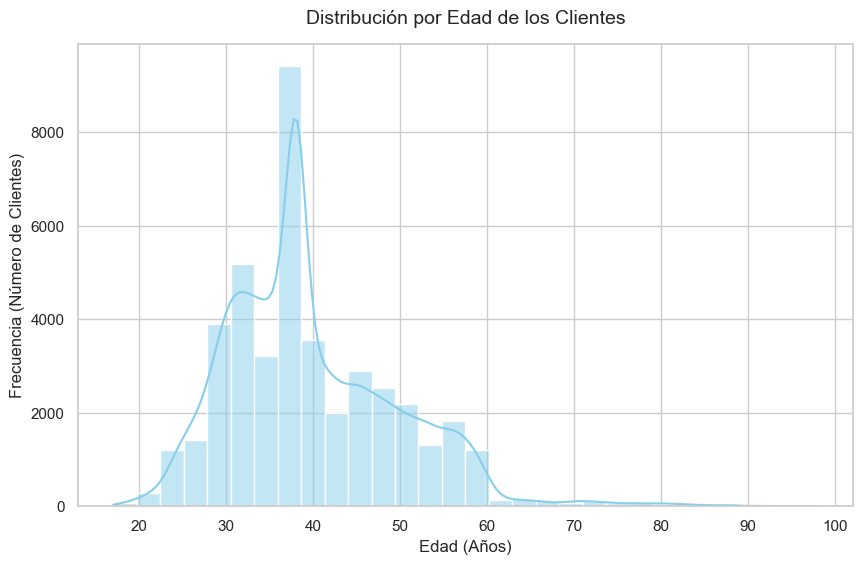

In [ ]:
#comienzo a explorar la distribución de algunas variables y luego pasaré a una exploración más analíticas de las variables de interés. 
#configuro previamente estilo del gráfico 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Gráfico 1: Histograma de la Edad con curva de densidad
sns.histplot(data=df, x='edad', kde=True, color='skyblue', bins=30)

#personalizo etiquetas
plt.title('Distribución por Edad de los Clientes', fontsize=14, pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)

plt.show()

/var/folders/hq/_m7l13_91j992d0_w2vrwt5w0000gn/T/ipykernel_21091/1872885841.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='empleo', order=order_empleo, palette='viridis')


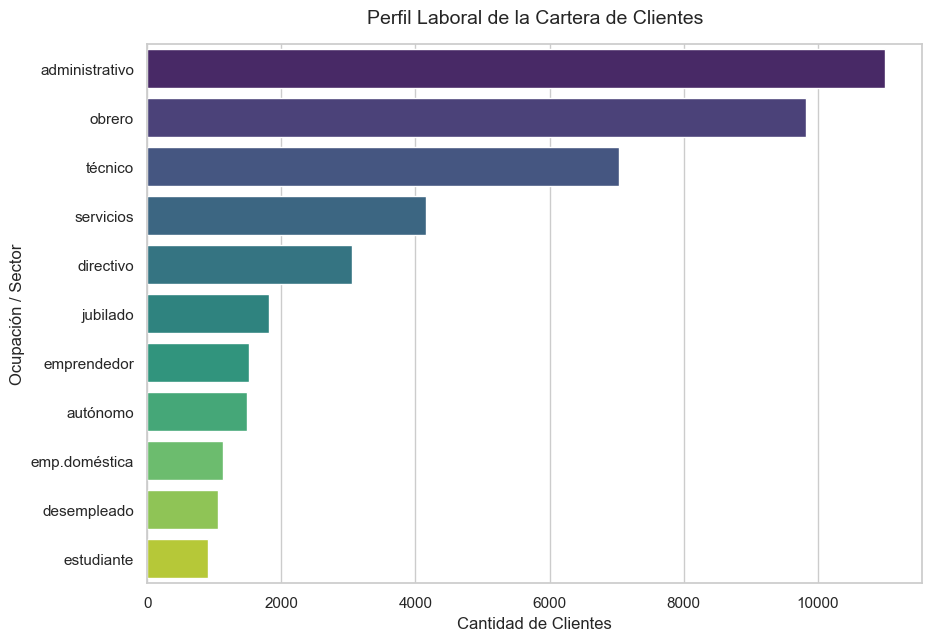

In [ ]:
#Gráfico 2: Frecuencias del Empleo
plt.figure(figsize=(10, 7))

#ordeno los valores de mi variable "Empleo" para mejor visualización
order_empleo = df['empleo'].value_counts().index

#gráfico de frecuencias
sns.countplot(data=df, y='empleo', order=order_empleo, palette='viridis')

#etiquetas
plt.title('Perfil Laboral de la Cartera de Clientes', fontsize=14, pad=15)
plt.xlabel('Cantidad de Clientes', fontsize=12)
plt.ylabel('Ocupación / Sector', fontsize=12)

plt.show()

/var/folders/hq/_m7l13_91j992d0_w2vrwt5w0000gn/T/ipykernel_21091/3647095274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='nivel_educativo', order=order_edu, palette='magma')


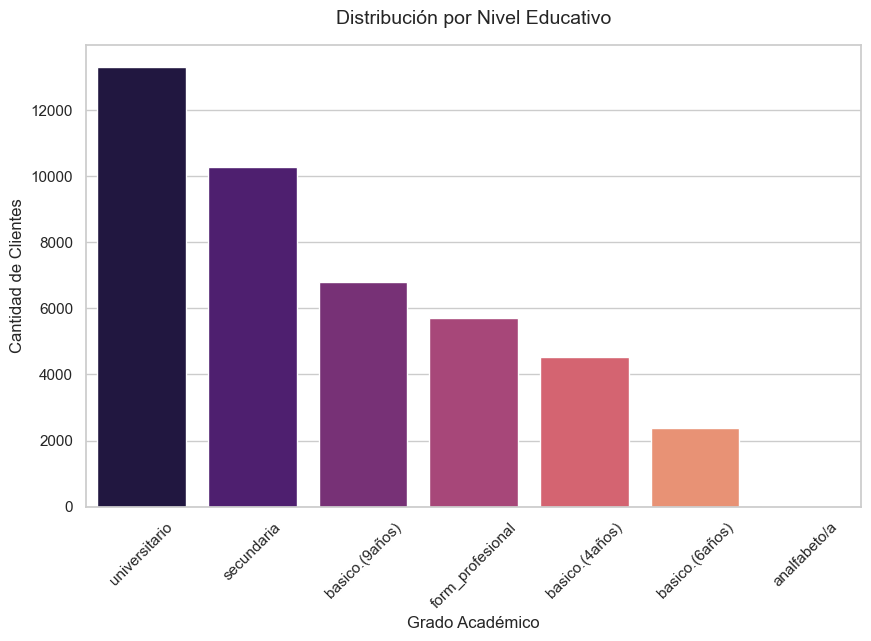

In [ ]:
#Gráfico 3: Distribución de Nivel Educativo
plt.figure(figsize=(10, 6))

#ordeno la variable "Nivel Educativo" para mejor visualización
order_edu = df['nivel_educativo'].value_counts().index

#gráfico de frecuencias
ax = sns.countplot(data=df, x='nivel_educativo', order=order_edu, palette='magma')

#giro las etiquetas del eje "x" por ser nombres largos
plt.xticks(rotation=45)
#etiquetas
plt.title('Distribución por Nivel Educativo', fontsize=14, pad=15)
plt.xlabel('Grado Académico', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

plt.show()

In [ ]:
#visualizo el porcentaje de clientes en cada segmento del ingreso
dist_ingresos = df['cat_ingreso_anual'].value_counts(normalize=True).sort_index() * 100
print("Distribución de clientes por segmento de ingresos:")
print(dist_ingresos.round(2))

Distribución de clientes por segmento de ingresos:
cat_ingreso_anual
Medio-Bajo    25.0
Bajo          25.0
Medio-Alto    25.0
Alto          25.0
Name: proportion, dtype: float64


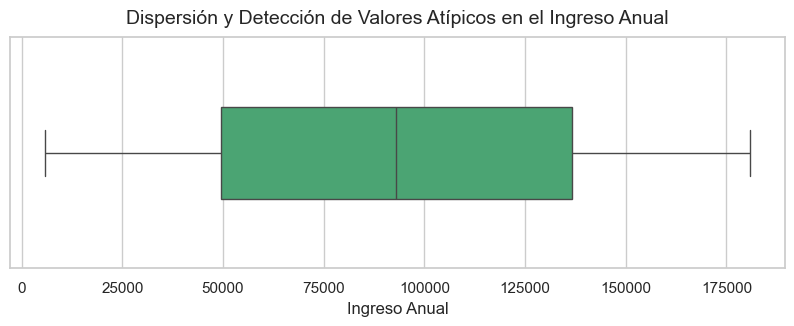

In [159]:
#el resultado anterior muestra que los grupos poblacionales de la segmentación del Ingreso están perfectamente distribuidos (logrado con 'qcut' previamente). Esto permitirá obtener un resultado más fiel (con sesgo bajo) a la hora de un análisis bivariado, por ej: cómo impacta cada segmento del ingreso en la variable objetivo de "Suscribir Producto/Servicio" bancario.

#Represento la Distribución del Ingreso Anual en un diagrama de caja (boxplot):
#configuro estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 3))

#Gráfico 4: Boxplot Ingreso Anual
sns.boxplot(data=df, x='ingreso_anual', color='mediumseagreen', width=0.4)

#personalizo etiquetas
plt.title('Dispersión y Detección de Valores Atípicos en el Ingreso Anual', fontsize=14, pad=10)
plt.xlabel('Ingreso Anual', fontsize=12)

plt.show()

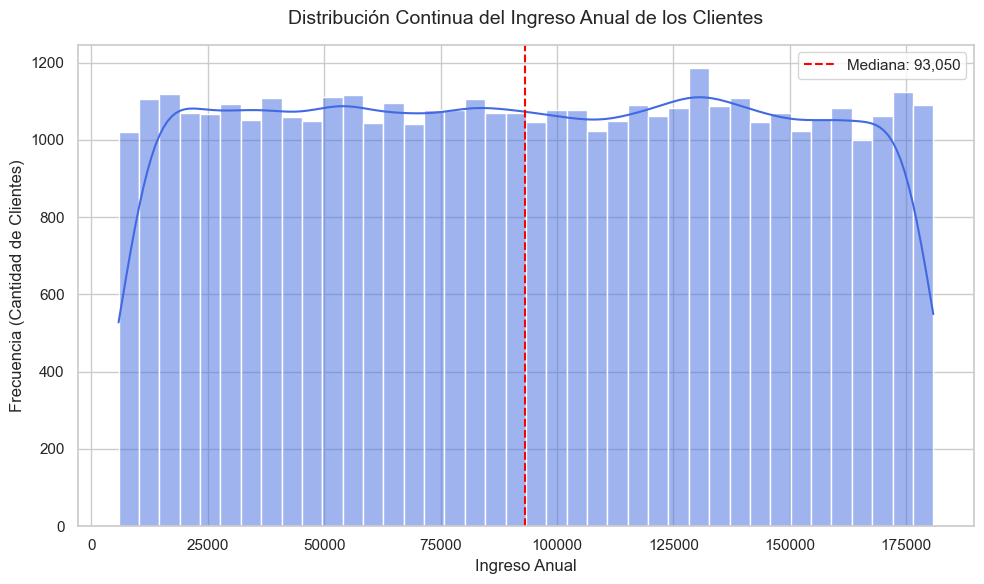

In [ ]:
#Represento la Distribución del Ingreso continuo para ver la distribución más detallada:
#configuro el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Gráfico 5: Distribución del Ingreso Anual (el parámetro "bins" agrupa el ingreso en 40 "cajones" para rmayor detalle)
sns.histplot(data=df, x='ingreso_anual', kde=True, bins=40, color='royalblue')

#personalizo etiquetas
plt.title('Distribución Continua del Ingreso Anual de los Clientes', fontsize=14, pad=15)
plt.xlabel('Ingreso Anual', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Clientes)', fontsize=12)
#agrego una línea punteada para marcar la Mediana (el cliente "del medio")
mediana_ingreso = df['ingreso_anual'].median()
plt.axvline(mediana_ingreso, color='red', linestyle='--', label=f'Mediana: {mediana_ingreso:,.0f}')
plt.legend()

plt.tight_layout() #ajuste del layout
plt.show()

/var/folders/hq/_m7l13_91j992d0_w2vrwt5w0000gn/T/ipykernel_21091/1570899448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='prod.serv_susc', palette='viridis')


Text(0.5, 1.0, 'Resultado de la Campaña (0=No, 1=Si)')

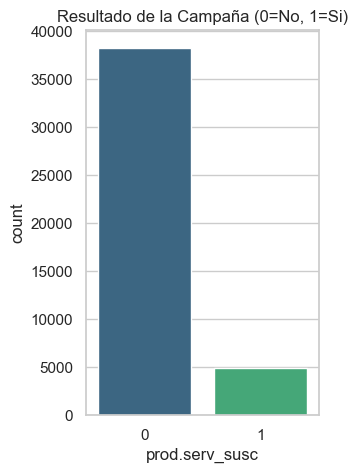

In [ ]:
#Gráfico 6: Éxito de la Suscripción
plt.figure(figsize=(3, 5))

sns.countplot(data=df, x='prod.serv_susc', palette='viridis')
plt.title('Resultado de la Campaña (0=No, 1=Si)')

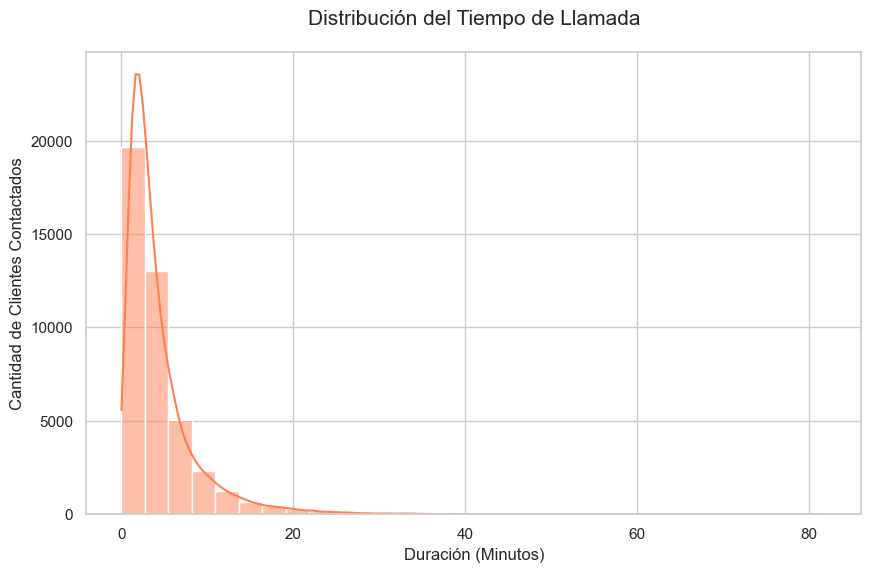

In [ ]:
#Gráfico 7: Distribución de la Duración de llamadas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

#visualizo Histograma de la duración de llamadas
sns.histplot(data=df, x='duracion_llam_min', bins=30, kde=True, color='coral')

#etiquetas
plt.title('Distribución del Tiempo de Llamada', fontsize=15, pad=20)
plt.xlabel('Duración (Minutos)', fontsize=12)
plt.ylabel('Cantidad de Clientes Contactados', fontsize=12)

plt.show()

/var/folders/hq/_m7l13_91j992d0_w2vrwt5w0000gn/T/ipykernel_21091/4282346457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='prod.serv_susc', y='ingreso_anual', palette='Set1', width=0.5)


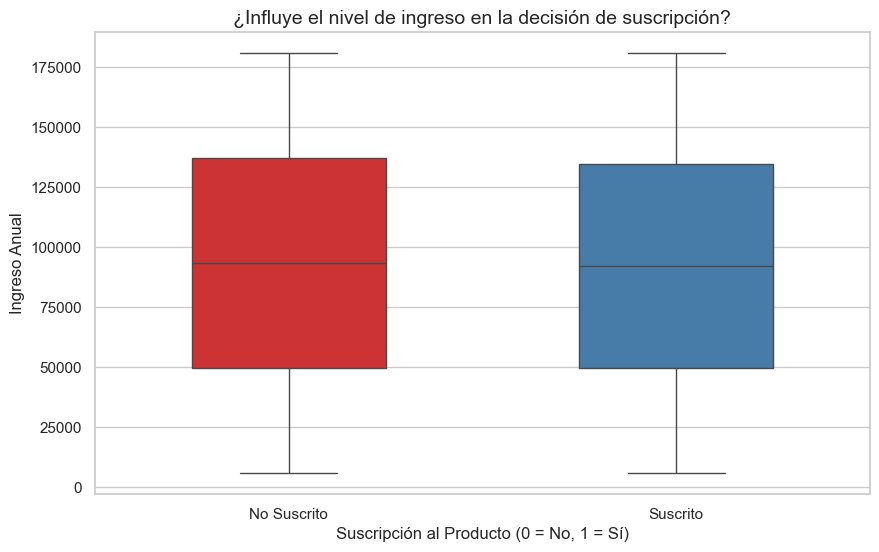

In [ ]:
#Comparativa del Ingreso Anual (continuo) según Suscripción del Producto/Servicio bancario, intentando averiguar si el producto es de consumo masivo o está ligado a la capacidad económica.

#Gráfico 8: Ingreso Anual - Suscripción (boxplots)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Boxplot comparativo (2 cajas): para los que dijeron "No" (0) y los que dijeron "Si" (1)
sns.boxplot(data=df, x='prod.serv_susc', y='ingreso_anual', palette='Set1', width=0.5)

#etiquetas
plt.title('¿Influye el nivel de ingreso en la decisión de suscripción?', fontsize=14)
plt.xlabel('Suscripción al Producto (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Ingreso Anual', fontsize=12)
plt.xticks([0, 1], ['No Suscrito', 'Suscrito'])

plt.show()

In [ ]:
#Chequeo los valores exactos del diagrama anterior (ingreso promedio de los que se suscribieron vs los que no) para especificar en mi informe
resumen_ingreso_exito = df.groupby('prod.serv_susc')['ingreso_anual'].agg(['mean', 'median', 'std']).round(2)
print(resumen_ingreso_exito)

                   mean   median       std
prod.serv_susc                            
0               93324.6  93206.5  50531.06
1               92584.3  92144.5  50240.01


Composición porcentual (No vs Si) por nivel educativo:


prod.serv_susc,0,1
cat_nivel_educativo,,
Alto,86.29,13.71
Bajo,91.18,8.82
Medio,88.67,11.33


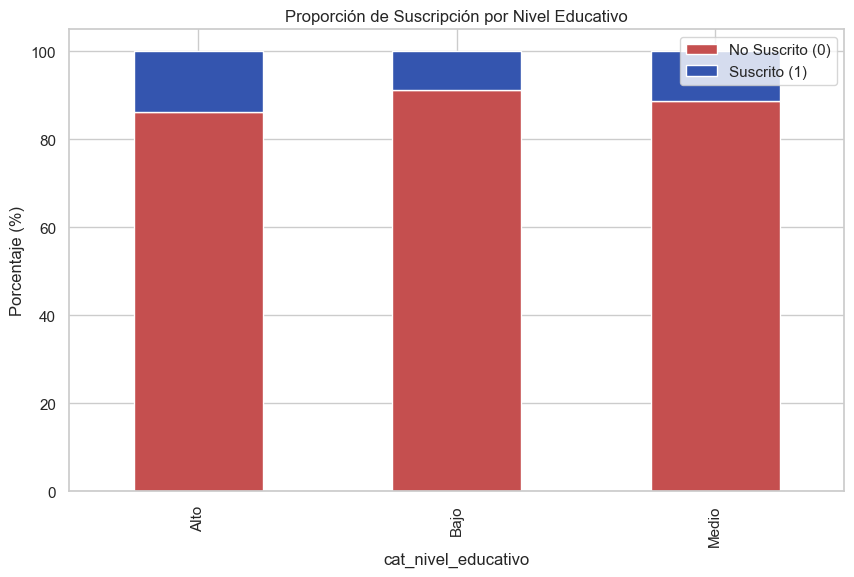

In [162]:
#Analizo la contingencia (normalizada) entre el Nivel Educativo y la Contratación de un Servicio/Producto (visualizo la proporción en cada nivel educativo)
tabla_educacion = pd.crosstab(df['cat_nivel_educativo'], df['prod.serv_susc'], normalize='index') * 100
print("Composición porcentual (No vs Si) por nivel educativo:")
display(tabla_educacion.round(2))

#Gráfico 9: Suscripción por Nivel Educativo (visualización de barras apiladas: Stacked Bar Chart)
tabla_educacion.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#c54f4fff","#3455af"])
plt.title('Proporción de Suscripción por Nivel Educativo')
plt.legend(['No Suscrito (0)', 'Suscrito (1)'], loc='upper right')
plt.ylabel('Porcentaje (%)')
plt.show()

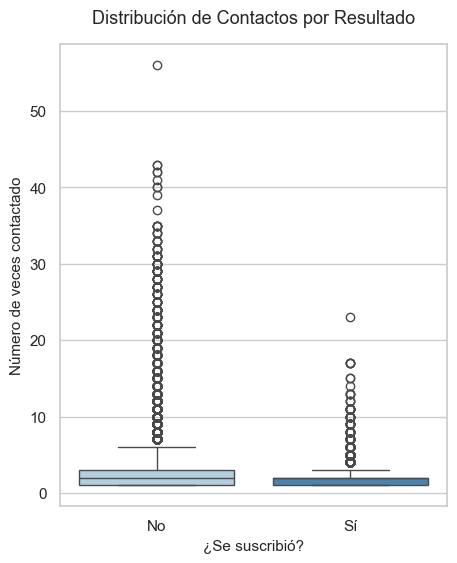

In [ ]:
#Gráfico 10: Boxplot Número de llamadas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

#visualizo Boxplot
sns.boxplot(data=df, x='prod.serv_susc', y='num_llam', palette='Blues', hue='prod.serv_susc', legend=False)

plt.title('Distribución de Contactos por Resultado', fontsize=13, pad=15)
plt.xlabel('¿Se suscribió?', fontsize=11)
plt.ylabel('Número de veces contactado', fontsize=11)
plt.xticks([0, 1], ['No', 'Sí'])
plt.show()

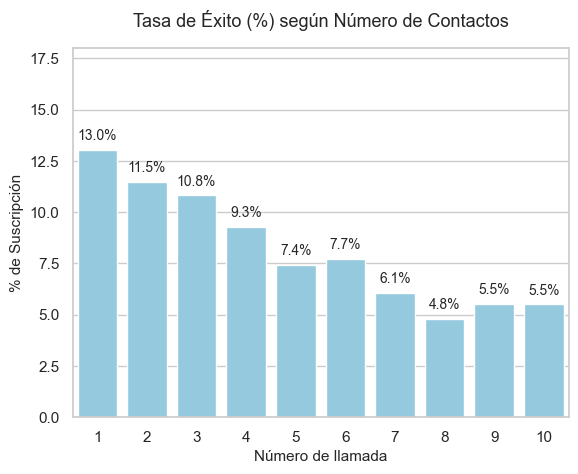

In [ ]:
#Análisis bivariado entre la Cantidad de llamadas y Suscripción al Producto/Servicio.
#previamente filtro hasta 10 llamadas
df_filtrado = df[df['num_llam'] <= 10]
tasa_exito_llam = df_filtrado.groupby('num_llam')['prod.serv_susc'].mean() * 100

#Gráfico 11: Tasa de Èxito: busco punto de saturación. (utilizo barplot de seaborn) 
ax = sns.barplot(x=tasa_exito_llam.index, y=tasa_exito_llam.values, color='skyblue')

#añado porcentajes sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')
    
plt.title('Tasa de Éxito (%) según Número de Contactos', fontsize=13, pad=15)
plt.xlabel('Número de llamada', fontsize=11)
plt.ylabel('% de Suscripción', fontsize=11)
plt.ylim(0, tasa_exito_llam.max() + 5)
plt.show()

/var/folders/hq/_m7l13_91j992d0_w2vrwt5w0000gn/T/ipykernel_21091/694507086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='prod.serv_susc', y='duracion_llam_min', palette='viridis', split=True)


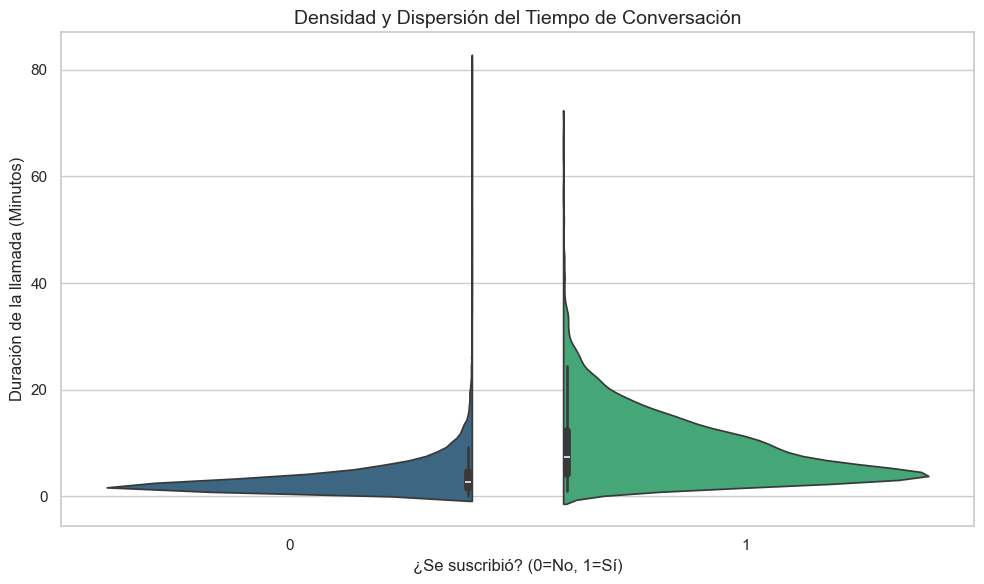

In [ ]:
#Análisis bivariado entre Duración de las llamadas y Suscripción del Prod/Servicio (éxito de la campaña). Busco determinar si el tiempo de la llamada es predictor del éxito de la campaña o no.
plt.figure(figsize=(10, 6))

#Gráfico 12: Violin-Plot combina un Boxplot con la densidad (KDE). Muestra dónde está "el grueso" de las llamadas exitosas
sns.violinplot(data=df, x='prod.serv_susc', y='duracion_llam_min', palette='viridis', split=True)

#etiquetas
plt.title('Densidad y Dispersión del Tiempo de Conversación', fontsize=14)
plt.xlabel('¿Se suscribió? (0=No, 1=Sí)', fontsize=12)
plt.ylabel('Duración de la llamada (Minutos)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
#valores numéricos de la eficiencia comercial (para el gráfico anterior)
analisis_eficiencia = df.groupby('prod.serv_susc').agg({
    'num_llam': ['mean', 'median', 'max'],
    'duracion_llam_min': ['mean', 'median', 'max']
    }).round(2)

print("Métricas de Esfuerzo Comercial por Resultado:")
display(analisis_eficiencia)

Métricas de Esfuerzo Comercial por Resultado:


num_llam            duracion_llam_min              
                   mean median max              mean median    max
prod.serv_susc                                                    
0                  2.63    2.0  56              3.67   2.72  81.97
1                  2.05    2.0  23              9.19   7.48  69.98

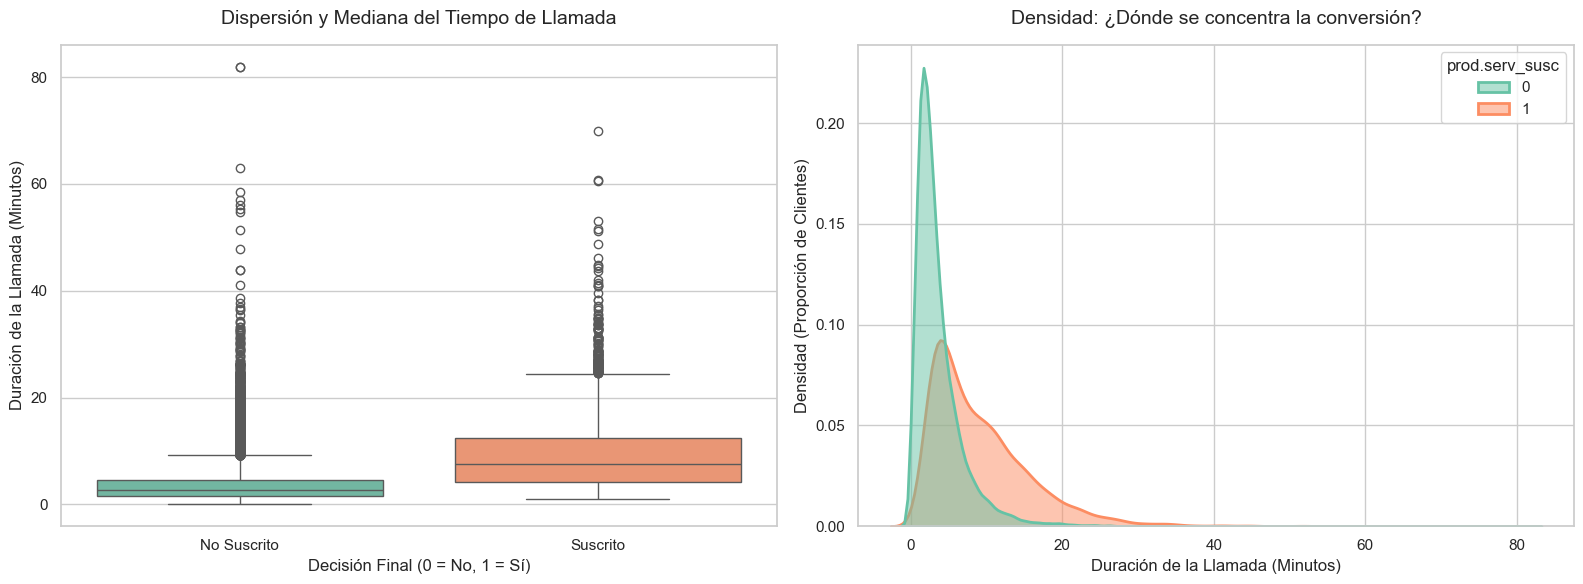

In [ ]:
#visualización complementaria para el Análisis bivariado entre Duración de las llamadas y Suscripción del Prod/Servicio.
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Gráfico 13 (izquierda): Dispersión del tiempo de la llamada
sns.boxplot(data=df, x='prod.serv_susc', y='duracion_llam_min', 
            palette='Set2', hue='prod.serv_susc', legend=False, ax=axes[0])

axes[0].set_title('Dispersión y Mediana del Tiempo de Llamada', fontsize=14, pad=15)
axes[0].set_xlabel('Decisión Final (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Duración de la Llamada (Minutos)', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Suscrito', 'Suscrito'])

#Gráfico 14 (derecha): Densidad del tiempo de la llamada (KDE plot), muestra dónde se concentra la mayor masa de clientes para cada resultado.
sns.kdeplot(data=df, x='duracion_llam_min', hue='prod.serv_susc', 
            fill=True, common_norm=False, palette='Set2', alpha=0.5, 
            linewidth=2, ax=axes[1])

axes[1].set_title('Densidad: ¿Dónde se concentra la conversión?', fontsize=14, pad=15)
axes[1].set_xlabel('Duración de la Llamada (Minutos)', fontsize=12)
axes[1].set_ylabel('Densidad (Proporción de Clientes)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
#cálculo de las métricas clave (para el gráfico anterior)
resumen_duracion = df.groupby('prod.serv_susc')['duracion_llam_min'].agg(
    Promedio='mean',
    Mediana='median',
    Desv_Estandar='std',
    Max_Minutos='max'
).round(2)

resumen_duracion.index = ['0 - No Suscrito', '1 - Suscrito']
print("Impacto del Tiempo en la Decisión de Suscribir (en minutos):")
display(resumen_duracion)

Impacto del Tiempo en la Decisión de Suscribir (en minutos):


,Promedio,Mediana,Desv_Estandar,Max_Minutos
0 - No Suscrito,3.67,2.72,3.45,81.97
1 - Suscrito,9.19,7.48,6.64,69.98


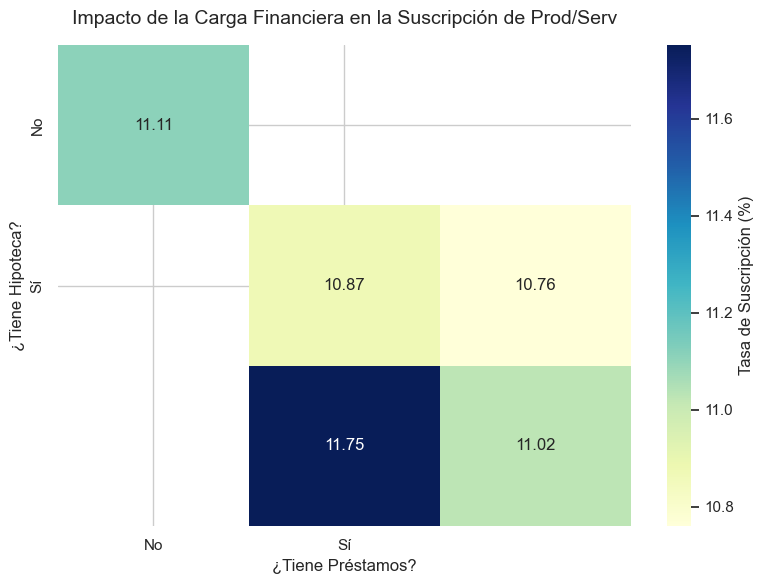

In [ ]:
#Gráfico 15: Heatmap de Carga Financiera al momento de Suscripción Prod/Serv. Busco averiguar qué peso tienen los prestamos e hipotecas a la hora de suscribir un Prod/Serv.
#primero creo una tabla dinámica (Pivot Table) con (prod.serv_susc) en valores, en filas: hipoteca y en columnas: prestamos
pivot_deuda = df.pivot_table(
    values='prod.serv_susc', 
    index='hipoteca', 
    columns='prestamos', 
    aggfunc='mean'
) * 100

#visualizo heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_deuda, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Tasa de Suscripción (%)'})

#etiquetas (asumiendo 0=No, 1=Sí)
plt.title('Impacto de la Carga Financiera en la Suscripción de Prod/Serv', fontsize=14, pad=15)
plt.xlabel('¿Tiene Préstamos?', fontsize=12)
plt.ylabel('¿Tiene Hipoteca?', fontsize=12)
plt.xticks([0.5, 1.5], ['No', 'Sí'])
plt.yticks([0.5, 1.5], ['No', 'Sí'])

plt.tight_layout()
plt.show()

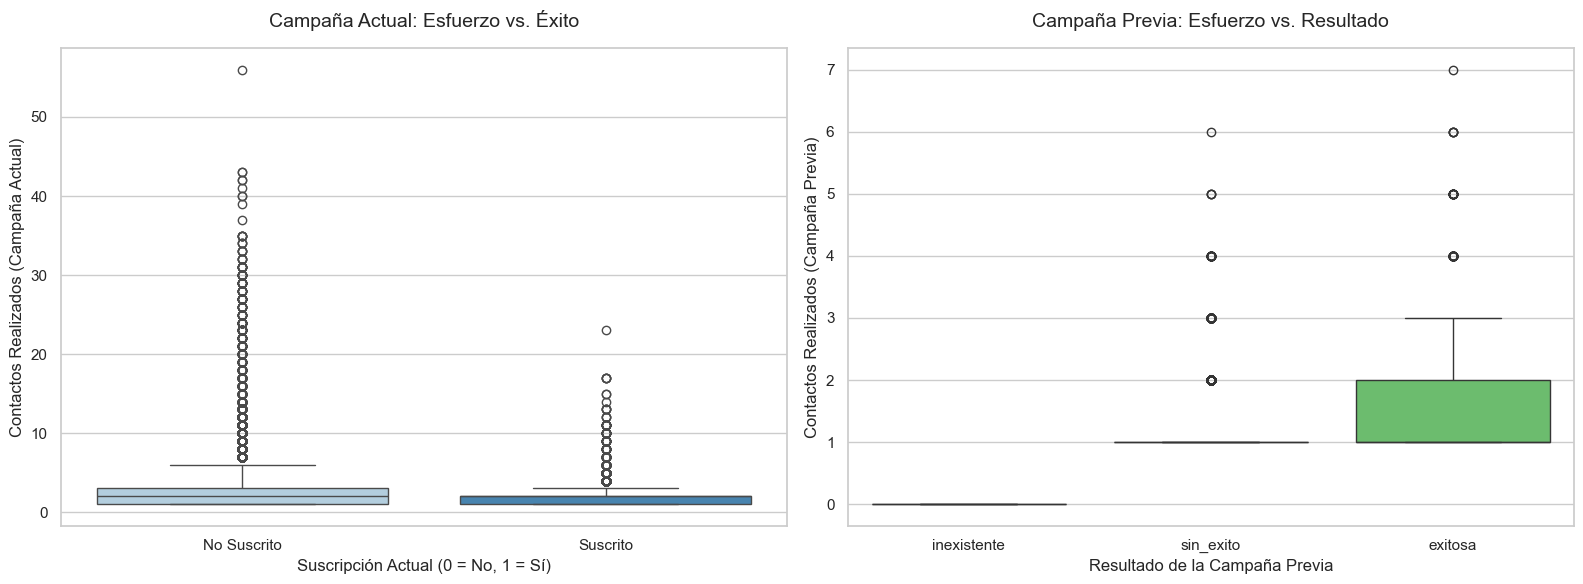

In [ ]:
#Análisis comparativo entre Campañas de Marketing: Actual vs Previa.
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Gráfico 16: Campaña Actual (número de llamadas vs éxito actual)
sns.boxplot(data=df, x='prod.serv_susc', y='num_llam', 
            palette='Blues', hue='prod.serv_susc', legend=False, ax=axes[0])

axes[0].set_title('Campaña Actual: Esfuerzo vs. Éxito', fontsize=14, pad=15)
axes[0].set_xlabel('Suscripción Actual (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Contactos Realizados (Campaña Actual)', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Suscrito', 'Suscrito'])

#Gráfico 17: Campaña Previa (número de llamadas previas vs resultado previo)
sns.boxplot(data=df, x='result_camp.previa', y='num_llam.camp.previa', 
            palette='viridis', hue='result_camp.previa', legend=False, ax=axes[1])

axes[1].set_title('Campaña Previa: Esfuerzo vs. Resultado', fontsize=14, pad=15)
axes[1].set_xlabel('Resultado de la Campaña Previa', fontsize=12)
axes[1].set_ylabel('Contactos Realizados (Campaña Previa)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
#complemento el gráfico con porcentajes del resultado de cada campaña:
print('Resultados CAMPAÑA ACTUAL (prod.serv_susc)')
actual_pct = df['prod.serv_susc'].value_counts(normalize = True) * 100

for categoria, porcentaje in actual_pct.items():
    label = "Suscrito (Sí)" if categoria == 1 else "No Suscrito (No)"
    print(f"{label}: {porcentaje:.2f}%")

print('======================================================')

print('Resultados CAMPAÑA ANTERIOR (result_camp.previa)')
previa_pct = df['result_camp.previa'].value_counts(normalize = True) * 100

for resultado, porcentaje in previa_pct.items():
    print(f"{resultado.capitalize()}: {porcentaje:.2f}%")

Resultados CAMPAÑA ACTUAL (prod.serv_susc)
No Suscrito (No): 88.73%
Suscrito (Sí): 11.27%
Resultados CAMPAÑA ANTERIOR (result_camp.previa)
Inexistente: 86.29%
Sin_exito: 10.37%
Exitosa: 3.34%
